In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import calendar as calmod
from matplotlib.ticker import PercentFormatter
from collections import defaultdict, deque
from pathlib import Path

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.0,
    "lines.markersize": 5.5,
})

TAB10 = ["#4E79A7","#F28E2B","#E15759","#76B7B2","#59A14F",
         "#EDC948","#B07AA1","#FF9DA7","#9C755F","#BAB0AC"]

# Data preparation
calendar = calendar.copy()
calendar["date"] = pd.to_datetime(calendar["date"])
d2date = calendar.set_index("d")["date"]
idx = pd.to_datetime([d2date[c] for c in day_cols])

if "sales_long" not in globals():
    sales_long = (
        df.melt(id_vars=["state_id","store_id","dept_id","cat_id","item_id"],
                value_vars=day_cols, var_name="d", value_name="units")
          .merge(calendar[["d","date"]], on="d", how="left")
    )
    sales_long["date"] = pd.to_datetime(sales_long["date"])

daily_total = pd.Series(df[day_cols].sum(axis=0).values, index=idx, name="units")

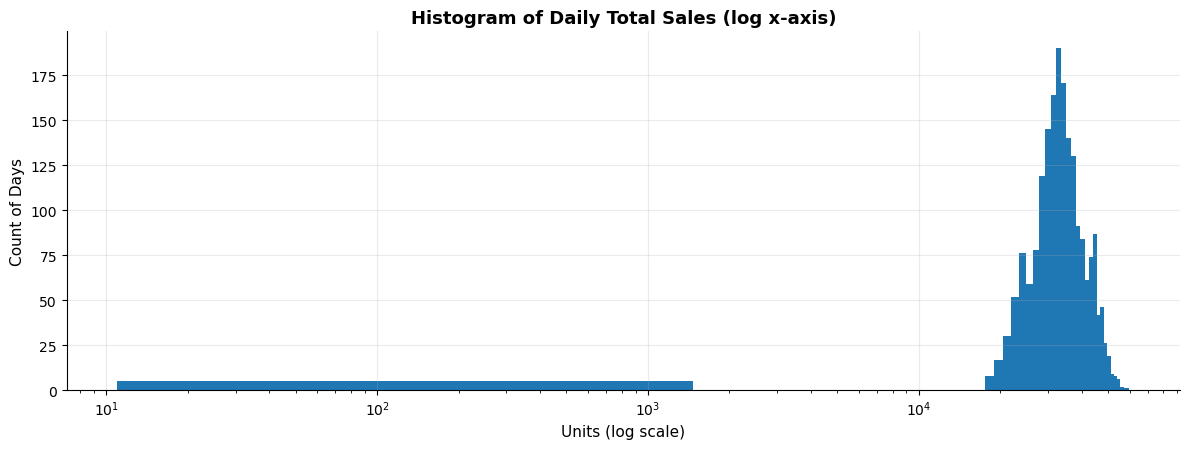

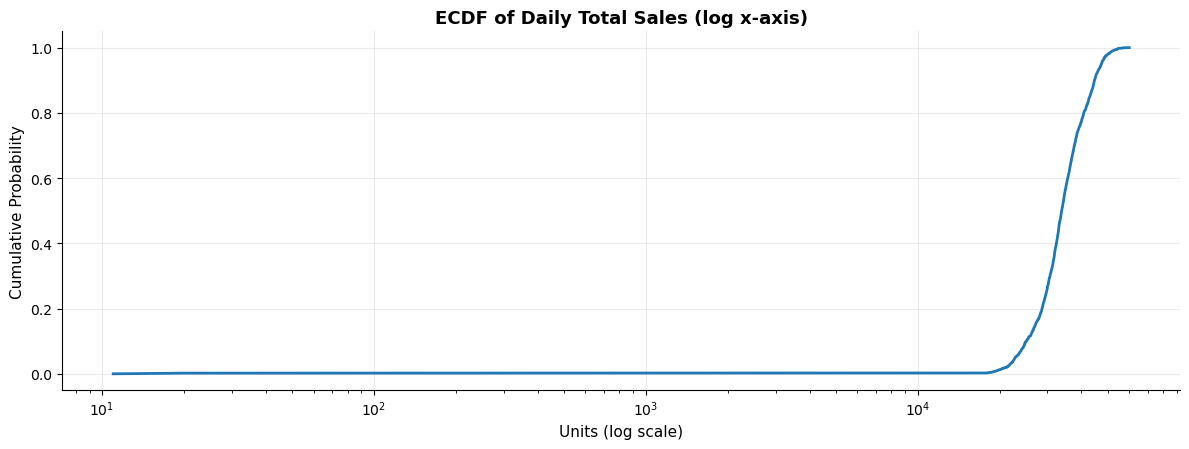

In [125]:
plt.figure()
plt.hist(daily_total.values, bins="auto")
plt.xscale("log")
plt.title("Histogram of Daily Total Sales (log x-axis)")
plt.xlabel("Units (log scale)"); plt.ylabel("Count of Days")
plt.tight_layout()
plt.show()

x_sorted = np.sort(daily_total.values)
y_ecdf = np.arange(1, len(x_sorted) + 1) / len(x_sorted)

plt.figure()
plt.plot(x_sorted, y_ecdf)
plt.xscale("log")
plt.title("ECDF of Daily Total Sales (log x-axis)")
plt.xlabel("Units (log scale)"); plt.ylabel("Cumulative Probability")
plt.tight_layout()
plt.show()

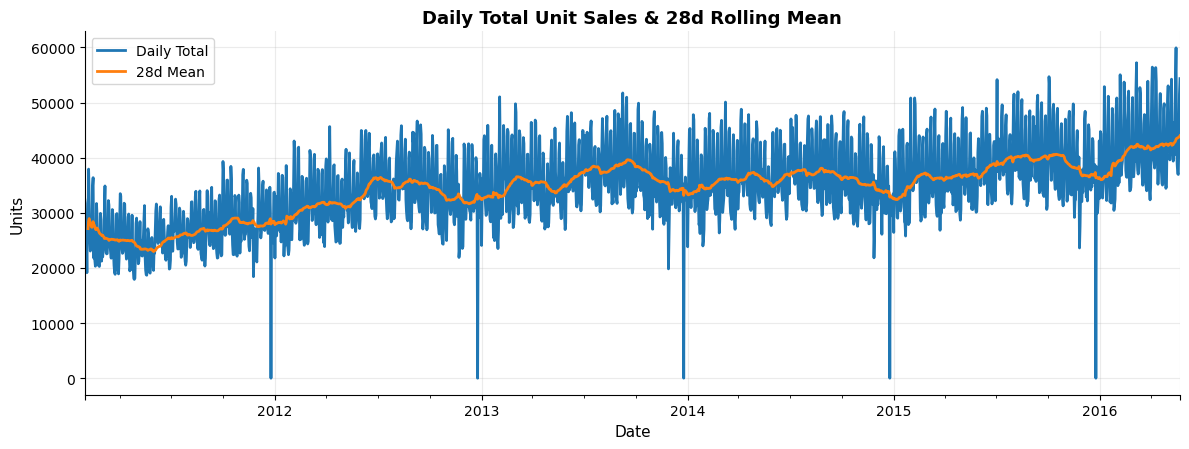

In [126]:
daily_total = pd.Series(df[day_cols].sum(axis=0).values, index=idx, name="total_sales")

roll = daily_total.rolling(28, min_periods=7)
daily_roll_mean = roll.mean()
daily_roll_std = roll.std()
daily_roll_cv = (daily_roll_std / (daily_roll_mean.replace(0, np.nan))).rename("cv_28d")

plt.figure()
daily_total.plot()
daily_roll_mean.plot()
plt.title("Daily Total Unit Sales & 28d Rolling Mean")
plt.xlabel("Date"); plt.ylabel("Units")
plt.legend(["Daily Total", "28d Mean"])
plt.tight_layout()
plt.show()

The series shows a clear intra-week cycle and a year-end holiday pattern with a pre-holiday ramp-up and a drop on/after the day.

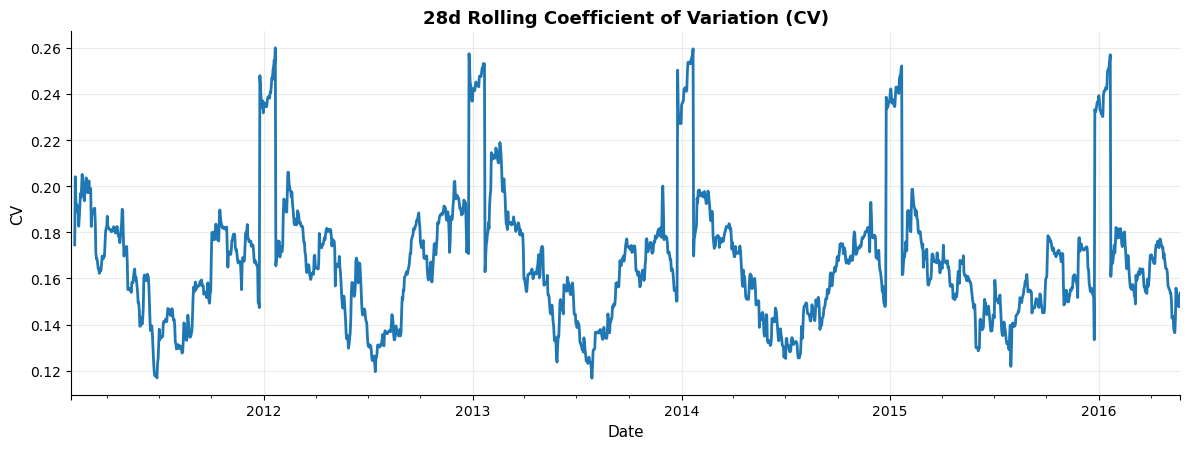

In [127]:
plt.figure()
daily_roll_cv.plot()
plt.title("28d Rolling Coefficient of Variation (CV)")
plt.xlabel("Date"); plt.ylabel("CV")
plt.tight_layout()
plt.show()

Volatility clusters around holiday/promo periods while other stretches remain relatively stable.

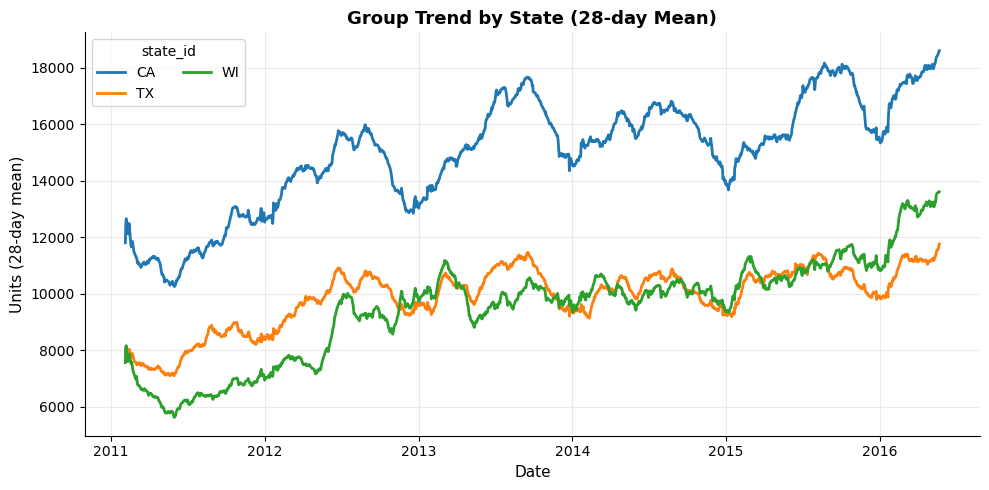

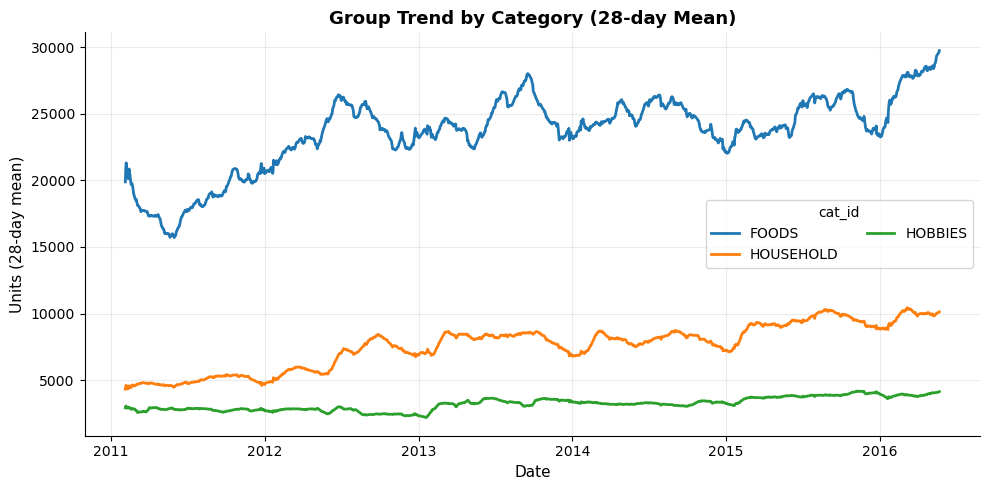

In [128]:
def plot_group_series_onefig(df, group_col, day_cols, title, top_k=5):
    series_per_group = {}
    for g, sub in df.groupby(group_col):
        s = pd.Series(sub[day_cols].sum(axis=0).values, index=idx, name=str(g))
        series_per_group[str(g)] = s

    avg_levels = pd.Series({k: v.mean() for k, v in series_per_group.items()}).sort_values(ascending=False)
    keep = list(avg_levels.head(top_k).index)

    plt.figure(figsize=(10, 5))
    for k in keep:
        s = series_per_group[k].rolling(28, min_periods=7).mean()
        plt.plot(s.index, s.values, label=k, linewidth=2)
    plt.title(title)
    plt.xlabel("Date"); plt.ylabel("Units (28-day mean)")
    plt.legend(title=group_col, ncol=2)
    plt.tight_layout()
    plt.show()

plot_group_series_onefig(df, "state_id", day_cols, title="Group Trend by State (28-day Mean)", top_k=5)
plot_group_series_onefig(df, "cat_id", day_cols, title="Group Trend by Category (28-day Mean)", top_k=3)

Daily totals are strongly right-skewed with a long tail and hints of weak multimodality. A large gap between the median and high quantiles confirms a heavy-tailed distribution.

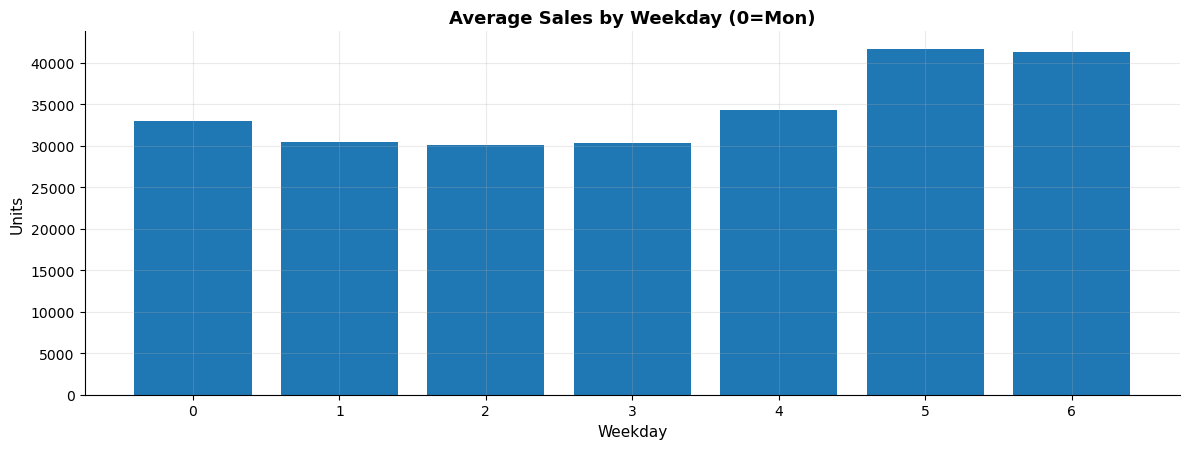

In [129]:
cal = calendar.set_index("date").copy()
cal.index = pd.to_datetime(cal.index)

tmp = pd.DataFrame({"date": daily_total.index, "y": daily_total.values})
tmp["weekday"] = tmp["date"].dt.weekday  # 0-6
weekday_stats = tmp.groupby("weekday")["y"].agg(["median","mean","std","count"])
weekday_stats["cv"] = weekday_stats["std"] / weekday_stats["mean"].replace(0, np.nan)

plt.figure()
plt.bar(weekday_stats.index, weekday_stats["mean"].values)
plt.title("Average Sales by Weekday (0=Mon)")
plt.xlabel("Weekday"); plt.ylabel("Units")
plt.tight_layout()
plt.show()

Consistent intra-week differences show some weekdays are reliably higher or lower.

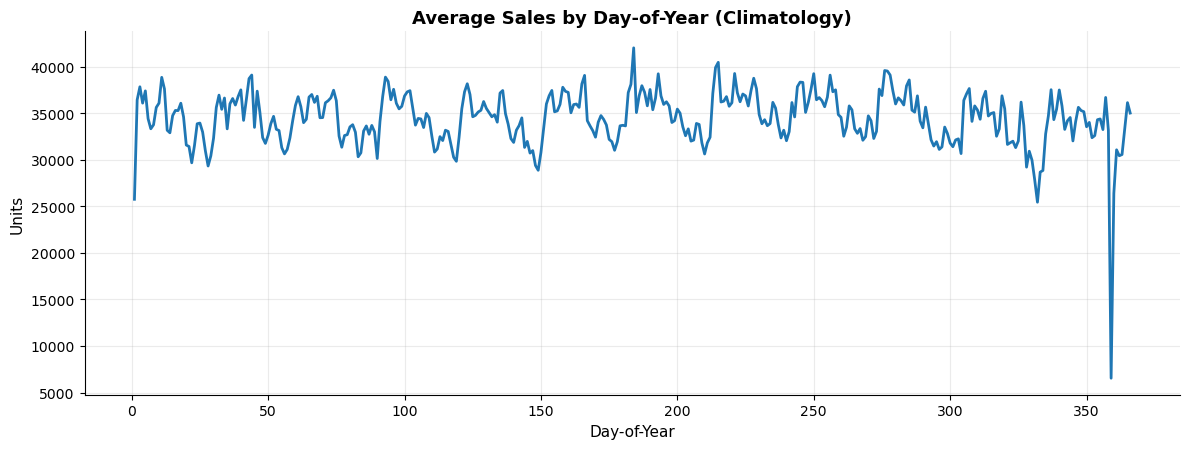

In [130]:
tmp["yday"] = tmp["date"].dt.dayofyear
yday_stats = tmp.groupby("yday")["y"].mean()

plt.figure()
yday_stats.plot()
plt.title("Average Sales by Day-of-Year (Climatology)")
plt.xlabel("Day-of-Year"); plt.ylabel("Units")
plt.tight_layout()
plt.show()

The yearly profile features a pre-holiday build-up and a sharp trough on 12/25.

States differ mainly in scale and seasonal amplitude while sharing similar shapes.

FOODS is steadier with a higher baseline, whereas HOBBIES/HOUSEHOLD swing more with seasons/holidays.

In [132]:
cal_ev = calendar.copy()
ev1 = cal_ev["event_type_1"].fillna("")
ev2 = cal_ev["event_type_2"].fillna("")
cal_ev["event_type_any"] = np.where(ev2 != "", ev1 + "|" + ev2, ev1)
cal_ev["is_event_day"] = cal_ev["event_type_any"].str.len() > 0

idx_dates = pd.to_datetime([calendar.set_index("d").loc[d, "date"] for d in day_cols])
daily_total_units = pd.DataFrame({"date": idx_dates, "units": df[day_cols].sum(axis=0).values})

evt_merged = daily_total_units.merge(
    cal_ev[["date","is_event_day","event_type_any"]],
    on="date", how="left"
)
evt_merged["is_event_day"] = evt_merged["is_event_day"].fillna(False)

mean_evt = evt_merged.groupby("is_event_day")["units"].mean()
overall_uplift = 100.0 * (mean_evt.get(True, np.nan) - mean_evt.get(False, np.nan)) / mean_evt.get(False, np.nan)
print(f"Event-day vs non-event-day mean difference: {overall_uplift:.2f}%")

Event-day vs non-event-day mean difference: -4.56%


No positive spikes at |Z|≥3, but strong negative anomalies occur on 12/25 across years.

In [133]:
rows = []
for _, r in evt_merged.iterrows():
    types = str(r["event_type_any"]).split("|") if pd.notna(r["event_type_any"]) and r["event_type_any"] != "" else []
    if not types:
        rows.append({"date": r["date"], "units": r["units"], "event_type": "None"})
    else:
        for t in types:
            rows.append({"date": r["date"], "units": r["units"], "event_type": t})
evt_flat = pd.DataFrame(rows)

mean_by_type = evt_flat.groupby("event_type")["units"].mean().sort_values(ascending=False)
base_type = mean_by_type.get("None", np.nan)
uplift_by_type = (100.0 * (mean_by_type - base_type) / base_type).drop(labels=["None"], errors="ignore").dropna()

sales_by_day_cat = sales_long.groupby(["date","cat_id"])["units"].sum().reset_index()
merged_cat = sales_by_day_cat.merge(cal_ev[["date","is_event_day"]], on="date", how="left")
merged_cat["is_event_day"] = merged_cat["is_event_day"].fillna(False)

cat_upl = {}
for g, sub in merged_cat.groupby("cat_id"):
    m = sub.groupby("is_event_day")["units"].mean()
    if (False in m.index) and (True in m.index):
        cat_upl[g] = 100.0 * (m[True] - m[False]) / m[False]
uplift_by_cat = pd.Series(cat_upl).sort_values(ascending=False)

sales_by_day_state = sales_long.groupby(["date","state_id"])["units"].sum().reset_index()
merged_state = sales_by_day_state.merge(cal_ev[["date","is_event_day"]], on="date", how="left")
merged_state["is_event_day"] = merged_state["is_event_day"].fillna(False)

state_upl = {}
for g, sub in merged_state.groupby("state_id"):
    m = sub.groupby("is_event_day")["units"].mean()
    if (False in m.index) and (True in m.index):
        state_upl[g] = 100.0 * (m[True] - m[False]) / m[False]
uplift_by_state = pd.Series(state_upl).sort_values(ascending=False)

print("Event impact analysis completed")

Event impact analysis completed


Negative anomalies align with Christmas, and SNAP flags are not prominent at the aggregate level.

/tmp/ipykernel_3453442/3462121544.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


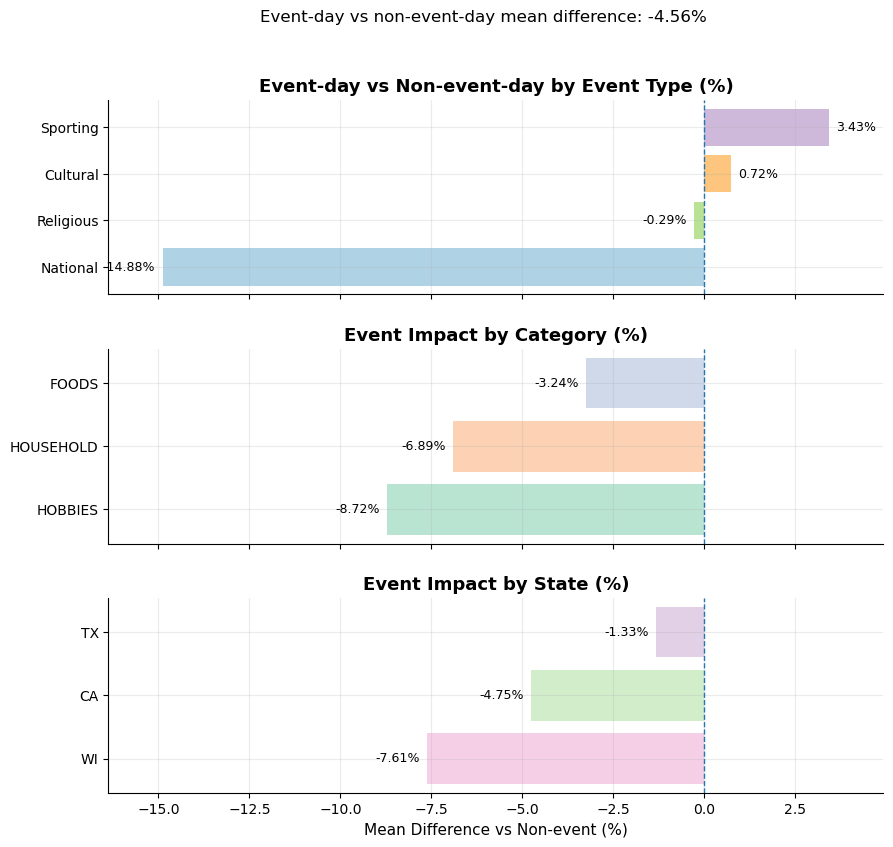

In [134]:
palette_event   = ["#A6CEE3","#B2DF8A","#FDBF6F","#CAB2D6","#FFFF99","#1F78B4","#33A02C","#FB9A99"]
palette_cat     = ["#B3E2CD","#FDCDAC","#CBD5E8"]
palette_state   = ["#F4CAE4","#CCEBC5","#DECBE4"]

def colors_for(index, palette):
    n = len(index)
    return [palette[i % len(palette)] for i in range(n)]

TOPK_EVENT = 8
top_event = uplift_by_type.sort_values(ascending=False).head(TOPK_EVENT)

fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(10, 9), gridspec_kw={"hspace": 0.28})

def draw_barh(ax, series, title, palette):
    s = pd.Series(series).dropna()
    if len(s) == 0:
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_title(title + " — (no data)")
        ax.set_yticks([])
        return
    s = s.sort_values(ascending=True)
    cols = colors_for(s.index, palette)
    bars = ax.barh(s.index, s.values, color=cols, edgecolor="none", alpha=0.9)
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(title)
    for rect, v in zip(bars, s.values):
        y = rect.get_y() + rect.get_height()/2
        x = rect.get_width()
        ax.text(x + (0.2 if v >= 0 else -0.2), y, f"{v:.2f}%", va="center",
                ha="left" if v >= 0 else "right", fontsize=9)

draw_barh(axes[0], top_event,       "Event-day vs Non-event-day by Event Type (%)", palette_event)
draw_barh(axes[1], uplift_by_cat,   "Event Impact by Category (%)",                 palette_cat)
draw_barh(axes[2], uplift_by_state, "Event Impact by State (%)",                    palette_state)

parts = [top_event, uplift_by_cat, uplift_by_state]
vals  = np.concatenate([np.asarray(p.dropna().values, dtype=float) for p in parts if len(p.dropna()) > 0]) if any(len(p.dropna())>0 for p in parts) else np.array([0.0])
xmin = float(np.nanmin(vals)); xmax = float(np.nanmax(vals))
pad = 0.1 * max(abs(xmin), abs(xmax), 1.0)
xmin, xmax = xmin - pad, xmax + pad
for ax in axes:
    ax.set_xlim(xmin, xmax)
axes[-1].set_xlabel("Mean Difference vs Non-event (%)")

fig.suptitle(f"Event-day vs non-event-day mean difference: {overall_uplift:.2f}%", y=0.98, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

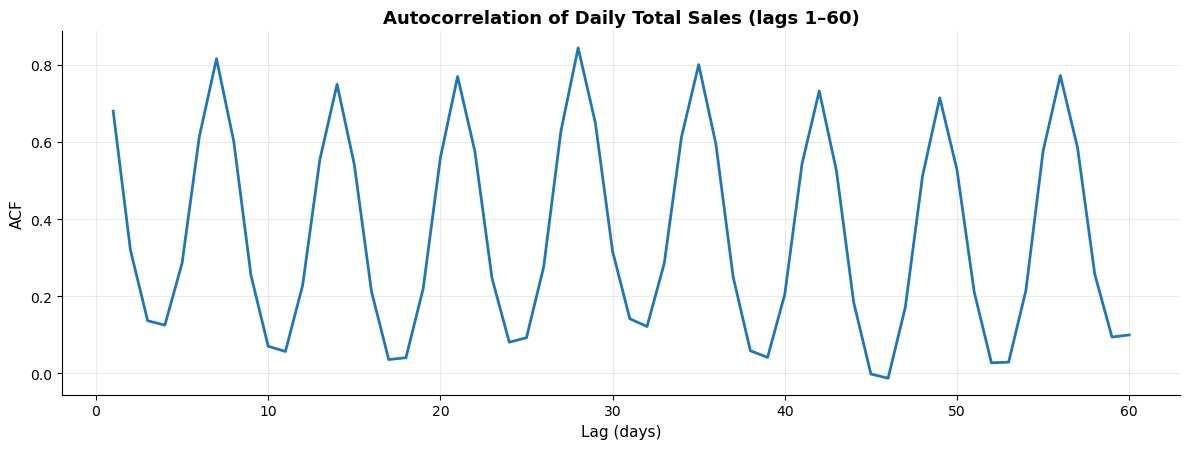

In [135]:
def autocorr(x, lag):
    x = np.asarray(x)
    x1 = x[lag:]
    x2 = x[:-lag]
    if x1.std() == 0 or x2.std() == 0:
        return np.nan
    return np.corrcoef(x1, x2)[0,1]

lags = range(1, 61)
acf = [autocorr(daily_total.values, L) for L in lags]

plt.figure()
plt.plot(list(lags), acf)
plt.title("Autocorrelation of Daily Total Sales (lags 1–60)")
plt.xlabel("Lag (days)"); plt.ylabel("ACF")
plt.tight_layout()
plt.show()

##### A strong weekly peak at lag=7 (with echoes at 14/21/28) indicates robust weekly periodicity.

/tmp/ipykernel_3453442/3966904791.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


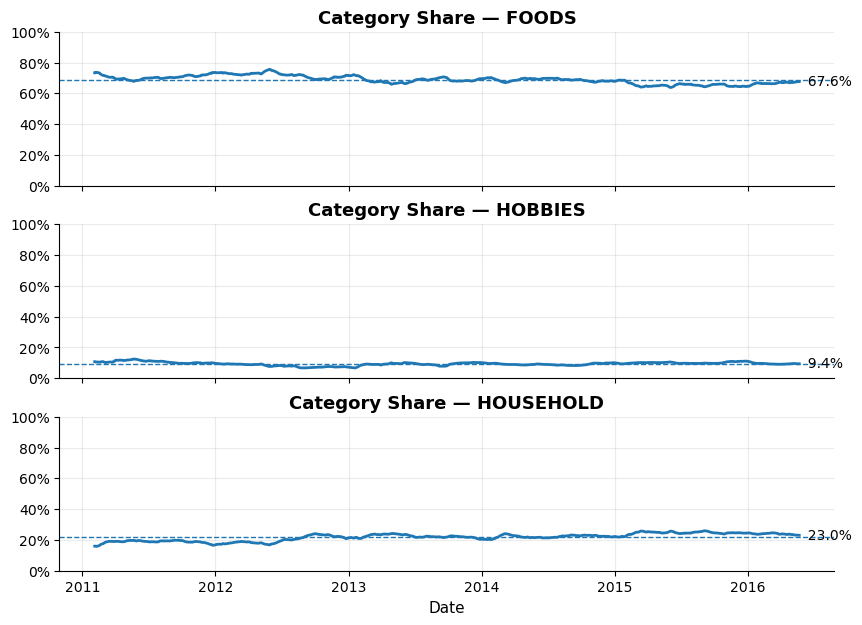

In [136]:
cat_series = {}
for cat, sub in df.groupby("cat_id"):
    s = pd.Series(sub[day_cols].sum(axis=0).values, index=idx, name=str(cat))
    cat_series[str(cat)] = s.rolling(28, min_periods=7).mean()

cats = sorted(cat_series.keys())
stack = pd.DataFrame({k: cat_series[k] for k in cats}).dropna()
stack_pct = stack.div(stack.sum(axis=1), axis=0)

overall_mean = stack_pct.mean(axis=0)
last_vals = stack_pct.iloc[-1]

fig, axes = plt.subplots(nrows=len(cats), ncols=1, sharex=True, figsize=(10, 7), gridspec_kw={"hspace": 0.25})

for i, cat in enumerate(cats):
    ax = axes[i] if len(cats) > 1 else axes
    s = stack_pct[cat]
    ax.plot(s.index, s.values, linewidth=2, label=f"{cat} share")
    ax.axhline(overall_mean[cat], linestyle="--", linewidth=1, label="overall mean")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.grid(alpha=0.25)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.set_title(f"Category Share — {cat}")
    ax.text(s.index[-1], s.values[-1], f"  {last_vals[cat]*100:.1f}%", va="center", ha="left")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

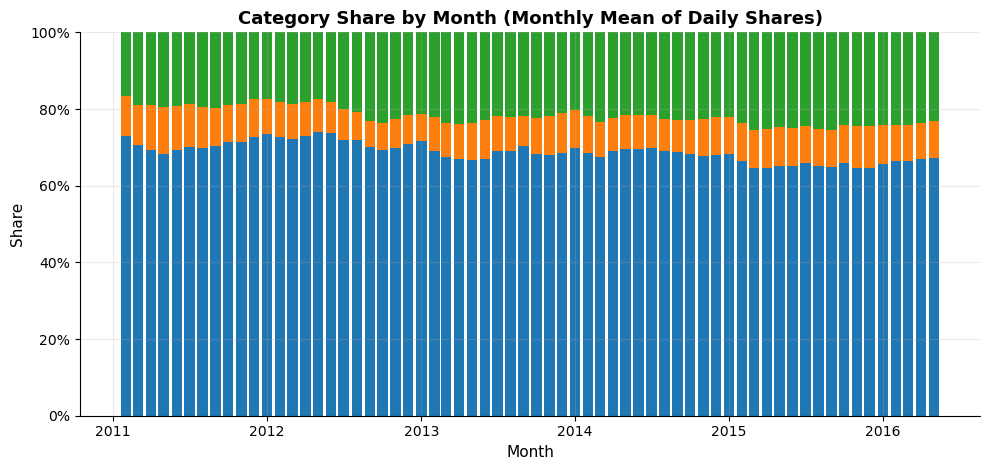

In [137]:
monthly_pct = (stack_pct.resample("MS").mean().dropna())

plt.figure(figsize=(10, 4.8))

bottom = np.zeros(len(monthly_pct))
x = monthly_pct.index
for cat in cats:
    y = monthly_pct[cat].values
    plt.bar(x, y, bottom=bottom, width=25, align="center")
    bottom = bottom + y

plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
plt.ylim(0, 1)
plt.title("Category Share by Month (Monthly Mean of Daily Shares)")
plt.xlabel("Month"); plt.ylabel("Share")
plt.grid(axis="y", alpha=0.25)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [138]:
price_state_cat = (sp_daily_meta
                   .groupby(["date","state_id","cat_id"])["sell_price"]
                   .mean()
                   .rename("avg_price")
                   .reset_index())

sales_long = (
    df.melt(id_vars=["state_id","cat_id"], value_vars=day_cols,
            var_name="d", value_name="units")
      .merge(calendar[["d","date"]], on="d", how="left")
)

price_state_cat["date"] = pd.to_datetime(price_state_cat["date"])
sales_long["date"]      = pd.to_datetime(sales_long["date"])

price_state_cat["state_id"] = price_state_cat["state_id"].astype(str)
price_state_cat["cat_id"]   = price_state_cat["cat_id"].astype(str)
sales_long["state_id"]      = sales_long["state_id"].astype(str)
sales_long["cat_id"]        = sales_long["cat_id"].astype(str)

sales_state_cat_daily = (sales_long
                         .groupby(["date","state_id","cat_id"])["units"]
                         .sum()
                         .reset_index())

sc = price_state_cat.merge(sales_state_cat_daily,
                           on=["date","state_id","cat_id"], how="inner")


[Overall] Event-day vs non-event-day mean difference: -4.56%


/tmp/ipykernel_3453442/1065262153.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


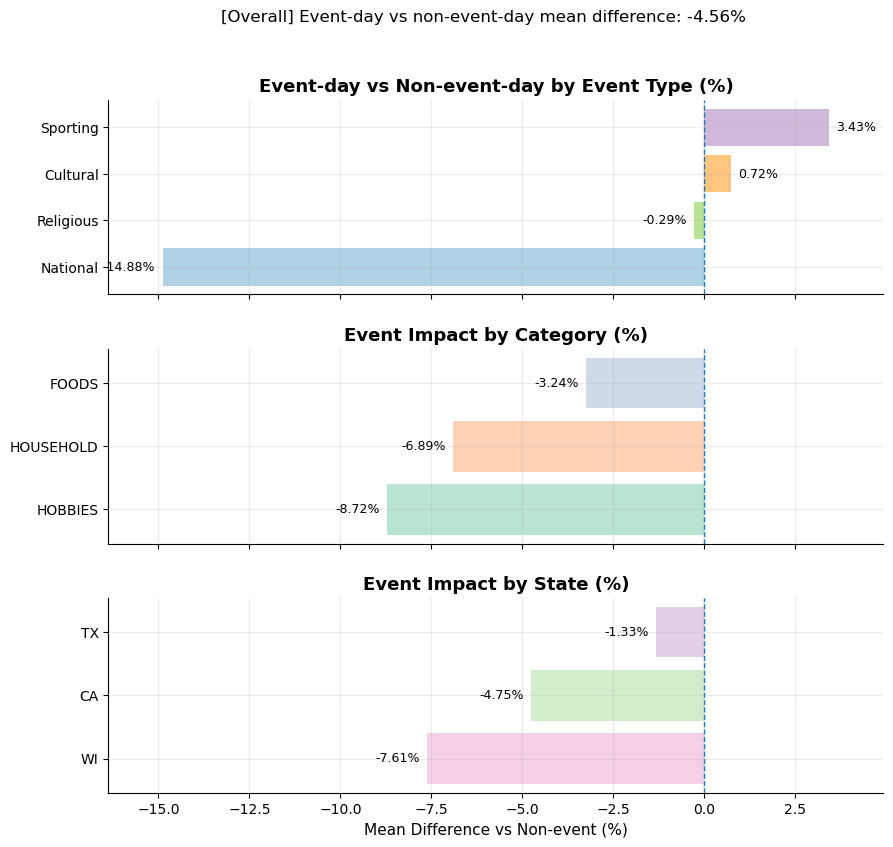

In [139]:
# === Event / Category / State uplift — 3 panels with soft colors & legends ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 0) Basic dtypes ----------
calendar = calendar.copy()
calendar["date"] = pd.to_datetime(calendar["date"])

# ---------- 1) Calendar event flags ----------
cal_ev = calendar.copy()
ev1 = cal_ev["event_type_1"].fillna("")
ev2 = cal_ev["event_type_2"].fillna("")
cal_ev["event_type_any"] = np.where(ev2 != "", ev1 + "|" + ev2, ev1)
cal_ev["is_event_day"] = cal_ev["event_type_any"].str.len() > 0

# ---------- 2) Daily total sales ----------
idx_dates = pd.to_datetime([calendar.set_index("d").loc[d, "date"] for d in day_cols])
daily_total_units = pd.DataFrame({"date": idx_dates, "units": df[day_cols].sum(axis=0).values})

evt_merged = daily_total_units.merge(
    cal_ev[["date","is_event_day","event_type_any"]],
    on="date", how="left"
)
evt_merged["is_event_day"] = evt_merged["is_event_day"].fillna(False)

mean_evt = evt_merged.groupby("is_event_day")["units"].mean()
overall_uplift = 100.0 * (mean_evt.get(True, np.nan) - mean_evt.get(False, np.nan)) / mean_evt.get(False, np.nan)
print(f"[Overall] Event-day vs non-event-day mean difference: {overall_uplift:.2f}%")

# ---------- 3) Uplift by EVENT TYPE ----------
rows = []
for _, r in evt_merged.iterrows():
    types = str(r["event_type_any"]).split("|") if pd.notna(r["event_type_any"]) and r["event_type_any"] != "" else []
    if not types:
        rows.append({"date": r["date"], "units": r["units"], "event_type": "None"})
    else:
        for t in types:
            rows.append({"date": r["date"], "units": r["units"], "event_type": t})
evt_flat = pd.DataFrame(rows)

mean_by_type = evt_flat.groupby("event_type")["units"].mean().sort_values(ascending=False)
base_type = mean_by_type.get("None", np.nan)
uplift_by_type = (100.0 * (mean_by_type - base_type) / base_type).drop(labels=["None"], errors="ignore").dropna()

# ---------- 4) sales_long (date, state_id, cat_id, units) ----------
if "sales_long" not in globals():
    sales_long = (
        df.melt(id_vars=["state_id","cat_id"], value_vars=day_cols, var_name="d", value_name="units")
          .merge(calendar[["d","date"]], on="d", how="left")
    )
sales_long["date"] = pd.to_datetime(sales_long["date"])
sales_long["state_id"] = sales_long["state_id"].astype(str)
sales_long["cat_id"]   = sales_long["cat_id"].astype(str)

# ---------- 5) Uplift by CATEGORY (bool-safe) ----------
sales_by_day_cat = sales_long.groupby(["date","cat_id"])["units"].sum().reset_index()
merged_cat = sales_by_day_cat.merge(cal_ev[["date","is_event_day"]], on="date", how="left")
merged_cat["is_event_day"] = merged_cat["is_event_day"].fillna(False)

cat_upl = {}
for g, sub in merged_cat.groupby("cat_id"):
    m = sub.groupby("is_event_day")["units"].mean()
    if (False in m.index) and (True in m.index):
        cat_upl[g] = 100.0 * (m[True] - m[False]) / m[False]
uplift_by_cat = pd.Series(cat_upl).sort_values(ascending=False)

# ---------- 6) Uplift by STATE (bool-safe) ----------
sales_by_day_state = sales_long.groupby(["date","state_id"])["units"].sum().reset_index()
merged_state = sales_by_day_state.merge(cal_ev[["date","is_event_day"]], on="date", how="left")
merged_state["is_event_day"] = merged_state["is_event_day"].fillna(False)

state_upl = {}
for g, sub in merged_state.groupby("state_id"):
    m = sub.groupby("is_event_day")["units"].mean()
    if (False in m.index) and (True in m.index):
        state_upl[g] = 100.0 * (m[True] - m[False]) / m[False]
uplift_by_state = pd.Series(state_upl).sort_values(ascending=False)

# ---------- 7) Soft color palettes ----------
# pastel-like palettes for each panel
palette_event   = ["#A6CEE3","#B2DF8A","#FDBF6F","#CAB2D6","#FFFF99","#1F78B4","#33A02C","#FB9A99"]
palette_cat     = ["#B3E2CD","#FDCDAC","#CBD5E8"]  # 3 cats → 3 soft colors
palette_state   = ["#F4CAE4","#CCEBC5","#DECBE4"]  # 3 states → 3 soft colors

def colors_for(index, palette):
    n = len(index)
    return [palette[i % len(palette)] for i in range(n)]

# ---------- 8) Plot (3 panels, soft colors + legends) ----------
TOPK_EVENT = 8
top_event = uplift_by_type.sort_values(ascending=False).head(TOPK_EVENT)

fig, axes = plt.subplots(
    nrows=3, ncols=1, sharex=True, figsize=(10, 9),
    gridspec_kw={"hspace": 0.28}
)

def draw_barh(ax, series, title, palette):
    s = pd.Series(series).dropna()
    if len(s) == 0:
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_title(title + " — (no data)")
        ax.set_yticks([])
        return
    s = s.sort_values(ascending=True)  # bottom→top
    cols = colors_for(s.index, palette)
    bars = ax.barh(s.index, s.values, color=cols, edgecolor="none", alpha=0.9)
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_title(title)
    # annotate values at bar ends
    for rect, v in zip(bars, s.values):
        y = rect.get_y() + rect.get_height()/2
        x = rect.get_width()
        ax.text(x + (0.2 if v >= 0 else -0.2), y, f"{v:.2f}%", va="center",
                ha="left" if v >= 0 else "right", fontsize=9)

draw_barh(axes[0], top_event,       "Event-day vs Non-event-day by Event Type (%)", palette_event)
draw_barh(axes[1], uplift_by_cat,   "Event Impact by Category (%)",                 palette_cat)
draw_barh(axes[2], uplift_by_state, "Event Impact by State (%)",                    palette_state)

# Unify x-limits for all panels
parts = [top_event, uplift_by_cat, uplift_by_state]
vals  = np.concatenate([np.asarray(p.dropna().values, dtype=float) for p in parts if len(p.dropna()) > 0]) if any(len(p.dropna())>0 for p in parts) else np.array([0.0])
xmin = float(np.nanmin(vals)); xmax = float(np.nanmax(vals))
pad = 0.1 * max(abs(xmin), abs(xmax), 1.0)
xmin, xmax = xmin - pad, xmax + pad
for ax in axes:
    ax.set_xlim(xmin, xmax)
axes[-1].set_xlabel("Mean Difference vs Non-event (%)")

fig.suptitle(f"[Overall] Event-day vs non-event-day mean difference: {overall_uplift:.2f}%", y=0.98, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


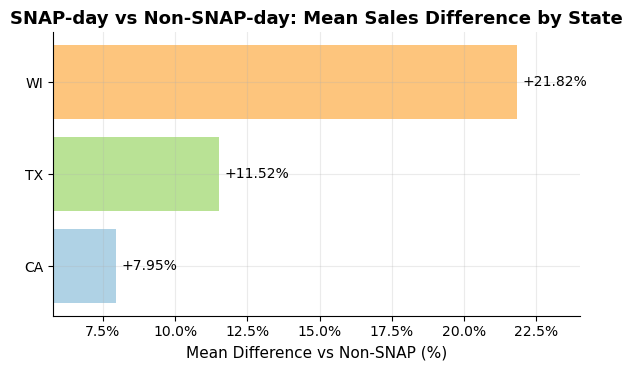

SNAP uplift by state (%): {'CA': '7.95', 'TX': '11.52', 'WI': '21.82'}


In [140]:
# === SNAP-day vs Non-SNAP-day — prettier one-figure bar chart ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

cal_snap = calendar.copy()
cal_snap["date"] = pd.to_datetime(cal_snap["date"])

# ensure sales_long exists
if "sales_long" not in globals():
    sales_long = (
        df.melt(id_vars=["state_id","cat_id"], value_vars=day_cols, var_name="d", value_name="units")
          .merge(calendar[["d","date"]], on="d", how="left")
    )
sales_long["date"] = pd.to_datetime(sales_long["date"])
sales_long["state_id"] = sales_long["state_id"].astype(str)

sales_state_daily = sales_long.groupby(["date","state_id"])["units"].sum().reset_index()

def snap_uplift_for_state(state_code, snap_col):
    sub = sales_state_daily[sales_state_daily["state_id"] == state_code].merge(
        cal_snap[["date", snap_col]], on="date", how="left"
    )
    sub[snap_col] = sub[snap_col].fillna(0).astype(int)
    mean_by_flag = sub.groupby(snap_col)["units"].mean()
    if 0 in mean_by_flag.index and 1 in mean_by_flag.index:
        return 100.0 * (mean_by_flag[1] - mean_by_flag[0]) / mean_by_flag[0]
    return np.nan

uplift = {
    "CA": snap_uplift_for_state("CA","snap_CA"),
    "TX": snap_uplift_for_state("TX","snap_TX"),
    "WI": snap_uplift_for_state("WI","snap_WI"),
}
uplift_s = pd.Series(uplift, name="uplift").dropna().sort_values(ascending=True)  # sort for barh

fig, ax = plt.subplots(figsize=(6, 3.8))

#bars = ax.barh(uplift_s.index, uplift_s.values)  # use default colors; clean and consistent
palette = ["#A6CEE3", "#B2DF8A", "#FDBF6F"]  # pastel
colors = [palette[i % len(palette)] for i in range(len(uplift_s))]
bars = ax.barh(uplift_s.index, uplift_s.values, color=colors, edgecolor="none", alpha=0.9)
ax.axvline(0, linestyle="--", linewidth=1)

# nice grid, spines, labels
ax.grid(axis="x", alpha=0.25)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# annotate values at bar-ends
for rect, v in zip(bars, uplift_s.values):
    y = rect.get_y() + rect.get_height()/2
    x = rect.get_width()
    ax.text(x + (0.2 if v >= 0 else -0.2), y, f"{v:+.2f}%", va="center",
            ha="left" if v >= 0 else "right", fontsize=10)

# x-axis as percent; pad limits for readability
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
pad = 0.1 * max(abs(uplift_s.min()), abs(uplift_s.max()), 1.0)
ax.set_xlim(uplift_s.min() - pad, uplift_s.max() + pad)

ax.set_title("SNAP-day vs Non-SNAP-day: Mean Sales Difference by State")
ax.set_xlabel("Mean Difference vs Non-SNAP (%)")

plt.tight_layout()
plt.show()

print("SNAP uplift by state (%):", {k: f"{v:.2f}" for k, v in uplift.items()})


/tmp/ipykernel_3453442/2631155929.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


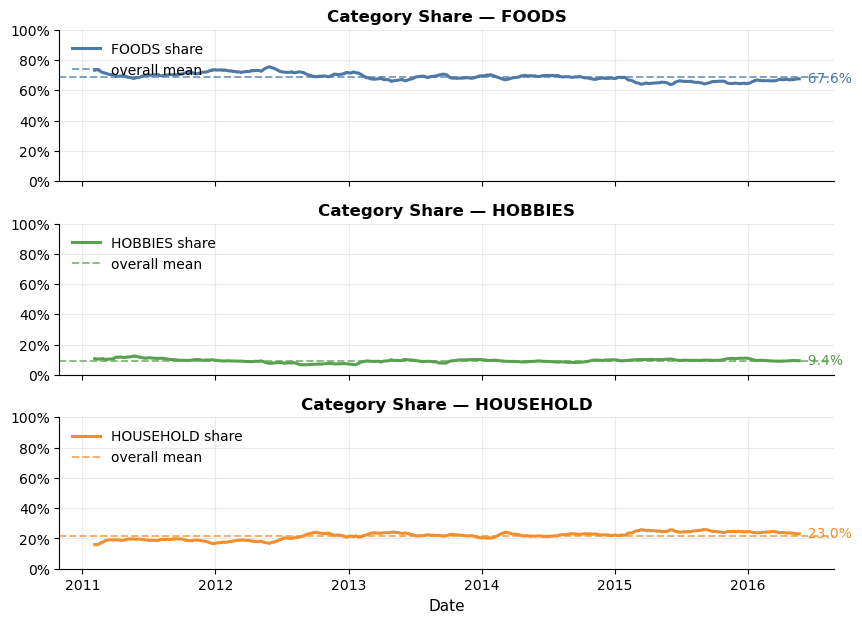

In [141]:
# === PRETTY Category share over time — 3 panels (28d mean + overall mean line) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ------------------ style (一次设置，全图生效) ------------------
plt.rcParams.update({
    "figure.figsize": (10, 7),
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.2,
})

def get_cat_palette(categories):
    base = ["#4E79A7", "#59A14F", "#F28E2B"]  # blue, green, orange
    return {c: base[i % len(base)] for i, c in enumerate(sorted(categories))}

cat_series = {}
for cat, sub in df.groupby("cat_id"):
    s = pd.Series(sub[day_cols].sum(axis=0).values, index=idx, name=str(cat))
    cat_series[str(cat)] = s.rolling(28, min_periods=7).mean()

cats = sorted(cat_series.keys())
stack = pd.DataFrame({k: cat_series[k] for k in cats}).dropna()
stack_pct = stack.div(stack.sum(axis=1), axis=0)   
overall_mean = stack_pct.mean(axis=0)              
last_vals = stack_pct.iloc[-1]                    

palette = get_cat_palette(cats)

fig, axes = plt.subplots(nrows=len(cats), ncols=1, sharex=True, gridspec_kw={"hspace": 0.28})

for i, cat in enumerate(cats):
    ax = axes[i] if len(cats) > 1 else axes
    s = stack_pct[cat]
    color = palette[cat]
    ax.plot(s.index, s.values, color=color, label=f"{cat} share")
    ax.axhline(overall_mean[cat], linestyle="--", linewidth=1.4, color=color, alpha=0.7, label="overall mean")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.set_title(f"Category Share — {cat}")
    ax.text(s.index[-1], s.values[-1], f"  {last_vals[cat]*100:.1f}%", va="center", ha="left", color=color, fontsize=10)
    ax.legend(loc="upper left", frameon=False)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


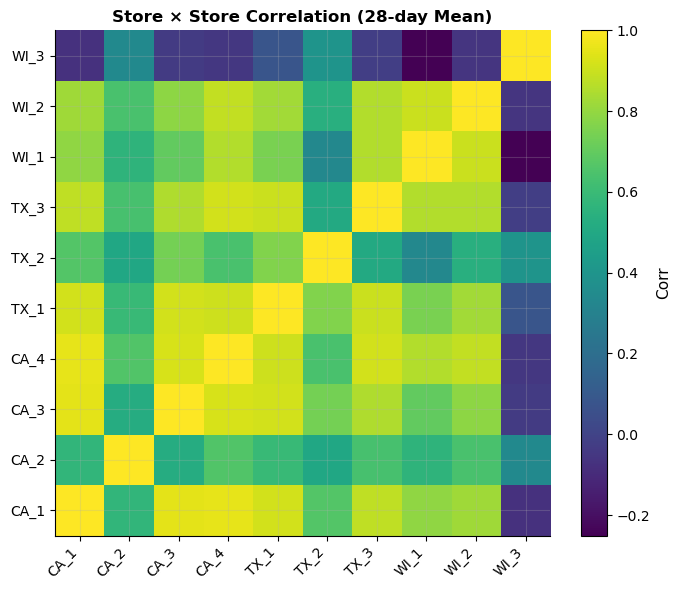

In [ ]:
store_series = {}
for st, sub in df.groupby("store_id"):
    s = pd.Series(sub[day_cols].sum(axis=0).values, index=idx, name=str(st))
    store_series[str(st)] = s.rolling(28, min_periods=7).mean()

S = pd.DataFrame(store_series).dropna()
corr = S.corr()

plt.figure(figsize=(7,6))
plt.imshow(corr.values, aspect="auto", origin="lower")
plt.colorbar(label="Corr")
plt.xticks(range(corr.shape[1]), corr.columns, rotation=45, ha="right")
plt.yticks(range(corr.shape[0]), corr.index)
plt.title("Store × Store Correlation (28-day Mean)")
plt.tight_layout(); plt.show()

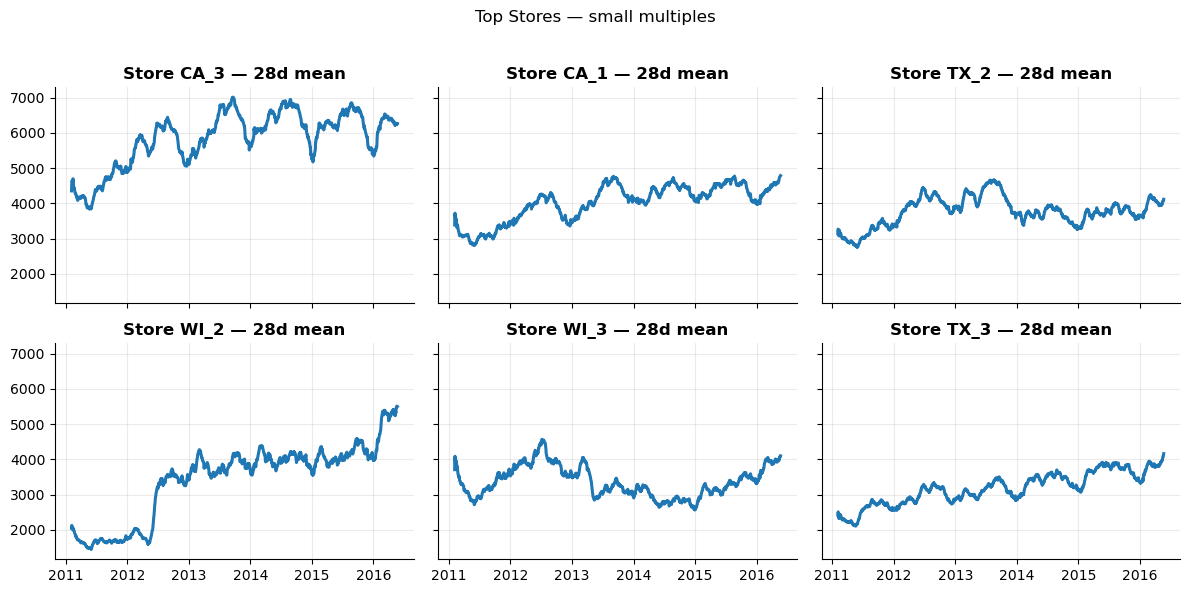

In [150]:
# === E. Top stores by volume — small multiples (28d mean) ===
import matplotlib.dates as mdates
if "sales_long" not in globals():
    sales_long = (
        df.melt(id_vars=["state_id","store_id","dept_id","cat_id","item_id"],
                value_vars=day_cols, var_name="d", value_name="units")
          .merge(calendar[["d","date"]], on="d", how="left")
    )
sales_long["date"]=pd.to_datetime(sales_long["date"])

top_stores = (sales_long.groupby("store_id")["units"].sum()
              .sort_values(ascending=False).head(6).index)
fig,axes=plt.subplots(2,3,figsize=(12,6),sharex=True,sharey=True)
axes=axes.ravel()
for i,st in enumerate(top_stores):
    s=(sales_long[sales_long["store_id"]==st]
       .groupby("date")["units"].sum().rolling(28,min_periods=7).mean())
    axes[i].plot(s.index, s.values)
    axes[i].set_title(f"Store {st} — 28d mean")
    axes[i].xaxis.set_major_locator(mdates.YearLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
for ax in axes: ax.grid(alpha=0.25)
fig.suptitle("Top Stores — small multiples", y=0.98, fontsize=12)
plt.tight_layout(rect=[0,0,1,0.96]); plt.show()


/tmp/ipykernel_3453442/2087570199.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slopes = sc_state.groupby("state_id", group_keys=False).apply(rolling_slope)


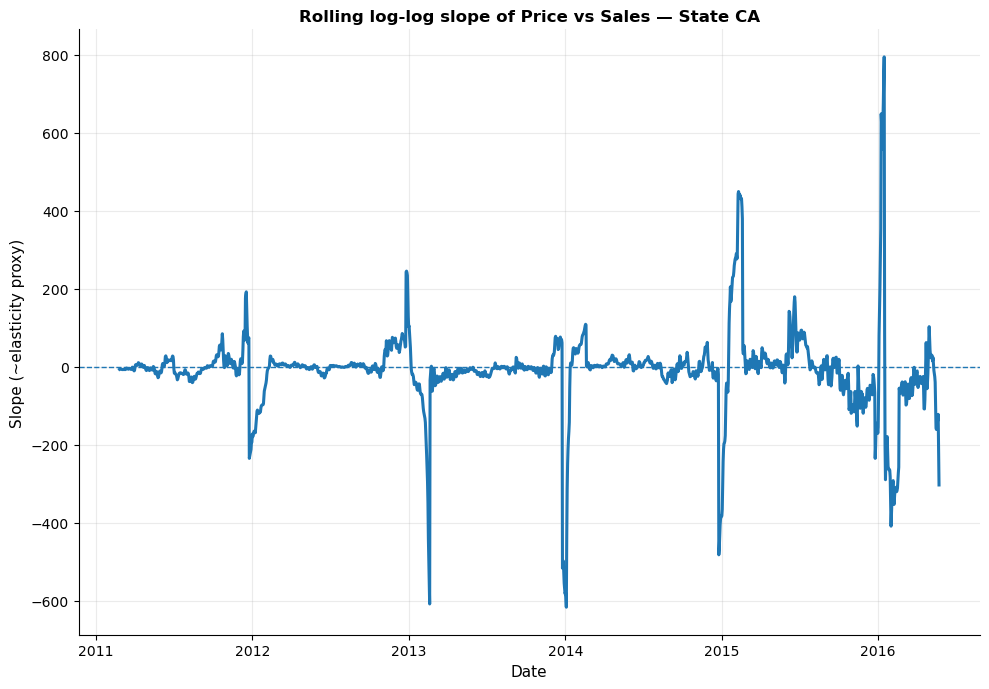

In [146]:
# === Rolling log-log slope between price and sales per state (coarse) ===
# 日均价（state）
price_state = (sp_daily_meta.groupby(["date","state_id"])["sell_price"].mean()
                          .rename("avg_price").reset_index())
# 日销量（state）
sales_state = sales_state_daily.copy()

sc_state = price_state.merge(sales_state, on=["date","state_id"], how="inner")
sc_state = sc_state.sort_values(["state_id","date"])
sc_state["lp"] = np.log(sc_state["avg_price"].clip(lower=1e-6))
sc_state["ly"] = np.log(sc_state["units"].clip(lower=1e-6))

def rolling_slope(df, win=56, minp=28):
    from collections import deque
    xs, ys, out = deque(), deque(), []
    for _, r in df.iterrows():
        xs.append(r["lp"]); ys.append(r["ly"])
        if len(xs) > win:
            xs.popleft(); ys.popleft()
        if len(xs) >= minp:
            # OLS slope: cov/var
            x = np.array(xs); y = np.array(ys)
            vx = np.var(x)
            slope = np.cov(x, y, ddof=0)[0,1] / vx if vx > 0 else np.nan
        else:
            slope = np.nan
        out.append(slope)
    df = df.copy(); df["roll_slope"] = out
    return df

slopes = sc_state.groupby("state_id", group_keys=False).apply(rolling_slope)

for st, sub in slopes.groupby("state_id"):
    plt.figure()
    plt.plot(sub["date"], sub["roll_slope"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Rolling log-log slope of Price vs Sales — State {st}")
    plt.xlabel("Date"); plt.ylabel("Slope (~elasticity proxy)")
    plt.tight_layout(); plt.show()


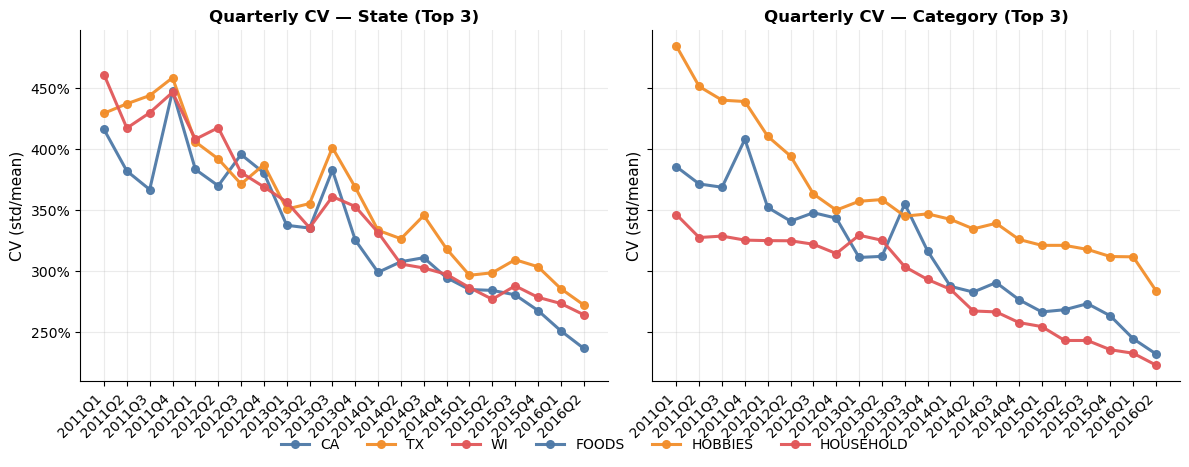

In [147]:
q_df = sales_long.copy()
q_df["date"] = pd.to_datetime(q_df["date"])
q_df["quarter"] = q_df["date"].dt.to_period("Q")

def quarterly_cv(df, by_col):
    g = (df.groupby([by_col, "quarter"])["units"]
           .agg(mean="mean", std="std", count="count")
           .reset_index())
    g["cv"] = g["std"] / g["mean"].replace(0, np.nan)
    rank = (g.groupby(by_col)["cv"].mean().sort_values(ascending=False))
    return g, rank

g_state, rank_state = quarterly_cv(q_df, "state_id")
g_cat,   rank_cat   = quarterly_cv(q_df, "cat_id")

TOPK_STATE = min(5, len(rank_state))
TOPK_CAT   = min(5, len(rank_cat))
keep_states = list(rank_state.head(TOPK_STATE).index)
keep_cats   = list(rank_cat.head(TOPK_CAT).index)

all_quarters = pd.period_range(q_df["quarter"].min(), q_df["quarter"].max(), freq="Q")

def to_wide_and_fill(g, key_col):
    wide = (g.pivot_table(index="quarter", columns=key_col, values="cv", aggfunc="mean").reindex(all_quarters))
    return wide

W_state = to_wide_and_fill(g_state[g_state["state_id"].isin(keep_states)], "state_id")
W_cat   = to_wide_and_fill(g_cat[g_cat["cat_id"].isin(keep_cats)], "cat_id")

def plot_panel(ax, wide_df, title):
    x = np.arange(len(wide_df.index))
    xlabels = [str(p) for p in wide_df.index]
    ax.set_title(title)
    cols = list(wide_df.columns)
    for i, c in enumerate(cols):
        y = wide_df[c].values
        ax.plot(x, y, marker="o", color=TAB10[i % len(TAB10)], label=str(c), alpha=0.95)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=45, ha="right")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.grid(alpha=0.25)
    ax.set_ylabel("CV (std/mean)")
    ax.axhline(0, linewidth=1, color="#999999", alpha=0.6)

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12, 4.6))

plot_panel(ax1, W_state * 1.0, f"Quarterly CV — State (Top {TOPK_STATE})")
plot_panel(ax2, W_cat   * 1.0, f"Quarterly CV — Category (Top {TOPK_CAT})")

all_vals = pd.concat([W_state, W_cat], axis=1).values
vmin = np.nanmin(all_vals); vmax = np.nanmax(all_vals)
pad = 0.05 * (vmax - vmin if np.isfinite(vmax - vmin) else 0.2)
yl, yh = max(0, vmin - pad), vmax + pad
for ax in (ax1, ax2):
    ax.set_ylim(yl, yh)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_lab = {}
for h, l in list(zip(handles1, labels1)) + list(zip(handles2, labels2)):
    by_lab[l] = h
fig.legend(by_lab.values(), by_lab.keys(), loc="lower center", ncol=min(6, len(by_lab)), frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

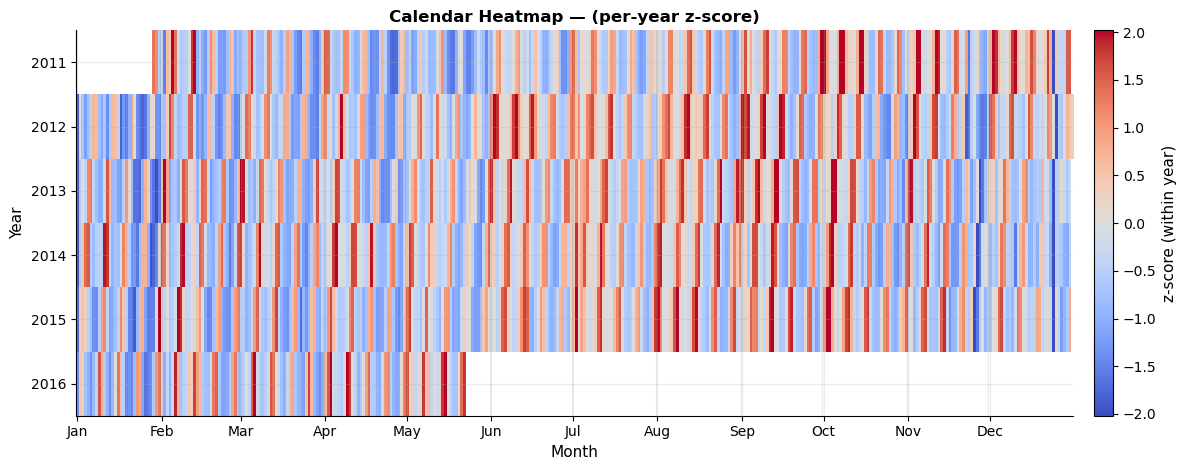

In [152]:
daily = pd.Series(df[day_cols].sum(axis=0).values, index=idx).sort_index().rename("units")
dfd = daily.reset_index().rename(columns={"index":"date"})
dfd["year"] = dfd["date"].dt.year
dfd["doy"]  = dfd["date"].dt.dayofyear
dfd["month"]= dfd["date"].dt.month

years = sorted(dfd["year"].unique())
max_doy = 366
M = np.full((len(years), max_doy), np.nan, dtype=float)
for i, y in enumerate(years):
    sub = dfd[dfd["year"]==y]
    M[i, sub["doy"].values-1] = sub["units"].values

def robust_scale(A, q=(2,98)):
    lo, hi = np.nanpercentile(A, q[0]), np.nanpercentile(A, q[1])
    return lo, hi

def plot_calendar_heatmap(M, years, metric="zscore", cmap="magma"):
    A = M.copy()
    label = "z-score (within year)"
    if metric == "log1p":
        A = np.log1p(A); label = "log1p(units)"
        vmin, vmax = robust_scale(A, (2,98))
    else:
        for i in range(A.shape[0]):
            row = A[i, :]
            mu  = np.nanmean(row); sd = np.nanstd(row)
            if np.isfinite(sd) and sd>0:
                A[i, :] = (row - mu) / sd
        vmin, vmax = robust_scale(A, (2,98))
        m = max(abs(vmin), abs(vmax)); vmin, vmax = -m, m
        cmap = "coolwarm"

    fig, ax = plt.subplots(figsize=(12, 4.8))
    A_mask = np.ma.masked_invalid(A)
    im = ax.imshow(A_mask, aspect="auto", interpolation="nearest",
                   cmap=cmap, vmin=vmin, vmax=vmax, origin="upper")

    ax.set_yticks(np.arange(len(years)))
    ax.set_yticklabels(years)
    ax.set_ylabel("Year")

    month_starts = []
    for m in range(1,13):
        dt = pd.Timestamp(2016, m, 1)
        month_starts.append(dt.dayofyear-1)
    ax.set_xticks(month_starts)
    ax.set_xticklabels([calmod.month_abbr[m] for m in range(1,13)], rotation=0)
    ax.set_xlabel("Month")

    for x in month_starts:
        ax.axvline(x-0.5, color="#000000", alpha=0.08, linewidth=1)

    im.cmap.set_bad(color=(1,1,1,0))
    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(label)

    title_suffix = "(per-year z-score)" if metric!="log1p" else "(log1p)"
    ax.set_title(f"Calendar Heatmap — {title_suffix}")

    plt.tight_layout()
    plt.show()

plot_calendar_heatmap(M, years, metric="zscore")

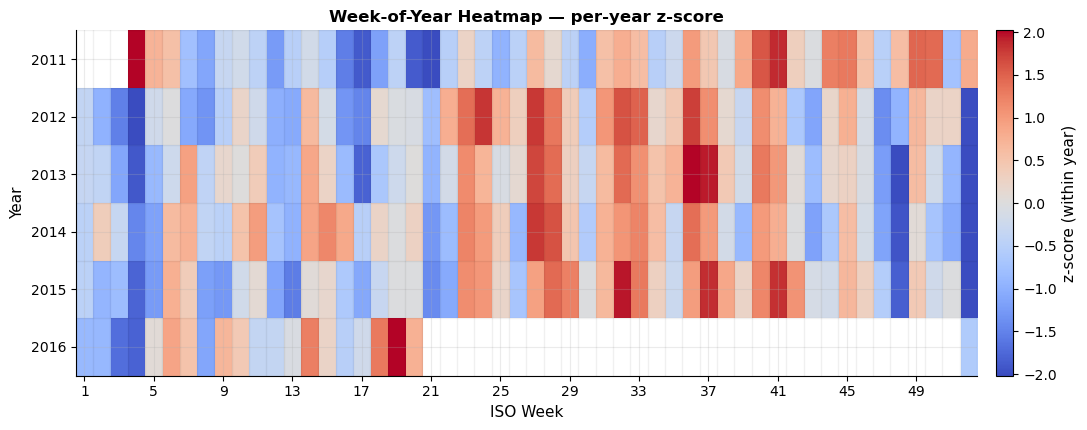

In [153]:
daily_units = pd.Series(df[day_cols].sum(axis=0).values, index=idx, name="units").sort_index()
wk = daily_units.reset_index().rename(columns={"index":"date"})
wk["year"] = wk["date"].dt.year
wk["woy"]  = wk["date"].dt.isocalendar().week.astype(int).clip(1, 52)

W = (wk.groupby(["year","woy"])["units"].mean().reset_index())
years = sorted(W["year"].unique())
M = np.full((len(years), 52), np.nan)
for i,y in enumerate(years):
    sub = W[W["year"]==y]
    M[i, sub["woy"].values-1] = sub["units"].values

Z = M.copy()
for i in range(Z.shape[0]):
    row = Z[i,:]
    mu, sd = np.nanmean(row), np.nanstd(row)
    if np.isfinite(sd) and sd>0:
        Z[i,:] = (row - mu)/sd

lo, hi = np.nanpercentile(Z, [2,98]); m = max(abs(lo), abs(hi)); vmin, vmax = -m, m

fig, ax = plt.subplots(figsize=(11, 4.4))
A = np.ma.masked_invalid(Z)
im = ax.imshow(A, aspect="auto", cmap="coolwarm", vmin=vmin, vmax=vmax)
im.cmap.set_bad(color=(1,1,1,0))
ax.set_yticks(np.arange(len(years))); ax.set_yticklabels(years); ax.set_ylabel("Year")
ax.set_xticks(np.arange(0,52,4)); ax.set_xticklabels(np.arange(1,53,4))
ax.set_xlabel("ISO Week")
ax.set_title("Week-of-Year Heatmap — per-year z-score")
for x in range(-1, 52): ax.axvline(x+0.5, color="#000", alpha=0.06, lw=1)
for y in range(-1, len(years)): ax.axhline(y+0.5, color="#000", alpha=0.06, lw=1)
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02); cbar.set_label("z-score (within year)")
plt.tight_layout(); plt.show()

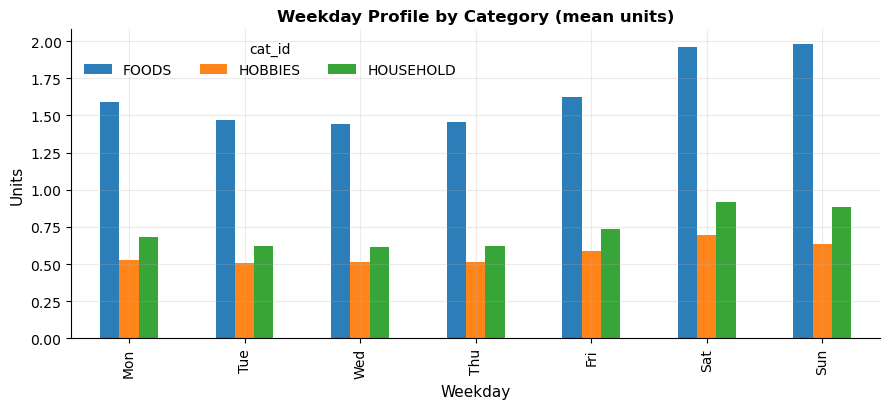

In [154]:
# Weekday pattern by category (bar chart)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from calendar import day_abbr

if "sales_long" not in globals():
    sales_long = (df.melt(id_vars=["state_id","store_id","dept_id","cat_id","item_id"],
                    value_vars=day_cols, var_name="d", value_name="units")
                    .merge(calendar[["d","date"]], on="d", how="left"))
sales_long["date"]=pd.to_datetime(sales_long["date"])
sales_long["wday"]=sales_long["date"].dt.weekday

wcat=(sales_long.groupby(["cat_id","wday"])["units"].mean()
      .reset_index().pivot(index="wday",columns="cat_id",values="units"))
wcat.index=[day_abbr[i] for i in wcat.index]

ax=wcat.plot(kind="bar",figsize=(9,4.2),alpha=0.95)
ax.set_title("Weekday Profile by Category (mean units)")
ax.set_xlabel("Weekday"); ax.set_ylabel("Units")
ax.grid(axis="y",alpha=0.25); ax.legend(title="cat_id",frameon=False,ncol=3)
plt.tight_layout(); plt.show()


/tmp/ipykernel_3453442/2022403654.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3453442/2022403654.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3453442/2022403654.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


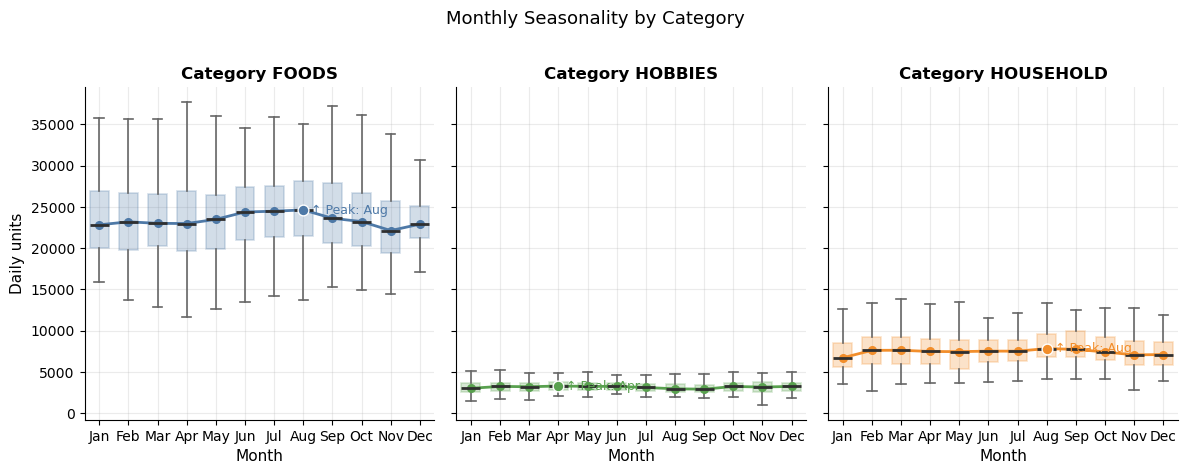

In [155]:
# === Pretty Monthly Seasonality by Category (colored boxplots + median line) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# 1) 数据准备：每类、每月的“按天聚合”的分布
m_long = (sales_long.assign(month=sales_long["date"].dt.month)
          .groupby(["cat_id","month","date"])["units"].sum()
          .reset_index())

cats = sorted(m_long["cat_id"].unique())
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# Tableau 配色（蓝/绿/橙）
cat_colors = {c: col for c, col in zip(cats, ["#4E79A7","#59A14F","#F28E2B"])}

plt.rcParams.update({
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, axes = plt.subplots(1, len(cats), sharey=True, figsize=(12, 4.6))

for i, cat in enumerate(cats):
    ax = axes[i] if len(cats) > 1 else axes
    sub = m_long[m_long["cat_id"] == cat]
    # 每月的“日销量分布”
    data = [sub.loc[sub["month"] == m, "units"].values for m in range(1, 13)]
    # 画彩色盒须图
    bp = ax.boxplot(
        data,
        labels=month_labels,
        showfliers=False,
        patch_artist=True,  # 允许填充色
        widths=0.65,
        medianprops=dict(color="#2F2F2F", linewidth=2.0),
        whiskerprops=dict(color="#666666", linewidth=1.2),
        capprops=dict(color="#666666", linewidth=1.2),
        boxprops=dict(linewidth=1.2, edgecolor=cat_colors[cat]),
    )
    # 给盒子填充柔和色
    for patch in bp["boxes"]:
        patch.set_facecolor(cat_colors[cat])
        patch.set_alpha(0.25)

    # 计算并叠加“月中位数”连线（更直观的趋势）
    medians = [np.median(d) if len(d) else np.nan for d in data]
    x = np.arange(1, 13)
    ax.plot(x, medians, marker="o", linewidth=2.0, color=cat_colors[cat], label="Median")

    # 高亮峰值月（中位数最大）
    if np.isfinite(np.nanmax(medians)):
        peak_idx = int(np.nanargmax(medians))
        ax.scatter([peak_idx + 1], [medians[peak_idx]],
                   s=60, color=cat_colors[cat], edgecolor="white", zorder=3)
        ax.text(peak_idx + 1, medians[peak_idx],
                f"  ↑ Peak: {month_labels[peak_idx]}",
                va="center", ha="left", fontsize=9, color=cat_colors[cat])

    ax.set_title(f"Category {cat}")
    ax.set_xlabel("Month")
    ax.tick_params(axis="x", rotation=0)

axes[0].set_ylabel("Daily units")
fig.suptitle("Monthly Seasonality by Category", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()
